이 노트북을 실행하는 데 필요한 라이브러리(표준 라이브러리 제외)
- torch
- torchvision
- torchinfo
- numpy
- matplotlib

- 실습 기본 환경 설정


In [1]:

# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED, deterministic=True)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()

CUDA를 사용합니다.


# 8-2 안정적으로 더 깊게 쌓기, 배치 정규화

본 노트북은 본문 8-2절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 배치 정규화 계층을 더한 `MiniVGGNetBN` 모델과 `MiniVGGNet`과의 성능 비교([표 8-3])
- 순전파 훅으로 확인하는 배치 정규화 계층 통과 전후의 평균과 표준편차
- 역전파 훅으로 확인하는 합성곱 계층 위치별 기울기 노름([표 8-4])

> 8장 코드 예제의 텐서 형태를 보여 주는 주석에는 배치 차원이 생략되어 있다.

## 8-1절과 공통으로 사용하는 코드

- 데이터로더는 8-1절과 같다(데이터 증강 적용).
- 비교를 위해 8-1절의 `MiniAlexNet`과 `MiniVGGNet` 클래스도 함께 정의한다.
    - 두 클래스의 설명은 8-1절 노트북(`08-01_example.ipynb`)을 참고하자.

In [2]:
# 참고 - CIFAR-10 데이터로더(8-1절 ~ 8-3절 공통)

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

# data_root: 데이터셋 다운로드 경로
data_root = '../../download'

# 데이터 변환 객체
CIFAR_MEAN = (0.5, 0.5, 0.5)
CIFAR_STD = (0.5, 0.5, 0.5)

# 검증, 평가 데이터셋 데이터 변환 객체 (증강 없음)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 훈련 데이터셋 데이터 변환 객체 (증강 추가)
train_transform = transforms.Compose([
    # 4 픽셀 패딩 후 32x32 크기로 무작위 자르기
    transforms.RandomCrop(32, padding=4),
    # 50% 확률로 좌우 반전
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 데이터셋 생성
TRAIN_SIZE, VALID_SIZE = 40000, 10000       # 훈련/검증 데이터셋의 크기

# 같은 데이터셋으로 증강 변환 적용/미적용 데이터셋을 생성

# 증강 변환 적용: 훈련용으로 사용
train_full = datasets.CIFAR10(
    root=data_root, train=True,
    download=True, transform=train_transform
    #download=True, transform=transform
)
# 증강 변환 미적용: 검증, 평가용으로 사용
valid_full = datasets.CIFAR10(
    root=data_root, train=True,
    download=True, transform=transform,
)

test_set = datasets.CIFAR10(
    root=data_root, train=False,
    download=True, transform=transform,
)

# 같은 기준으로 train_full과 valid_full을 분할해 훈련 데이터셋과 검증 데이터셋 생성
train_set, _ = random_split(train_full, [TRAIN_SIZE, VALID_SIZE], generator=torch.Generator().manual_seed(SEED))
# train_evaluate_set: 평가 시에는 증강 변환을 하지 않은 데이터셋 적용이 필요
train_evaluate_set, valid_set = random_split(valid_full, [TRAIN_SIZE, VALID_SIZE], generator=torch.Generator().manual_seed(SEED))

# 배치 크기 128인 데이터로더 생성
BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
train_evaluate_loader = DataLoader(train_evaluate_set, batch_size=BATCH_SIZE, shuffle=False)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [3]:
# 참고 - 8-1절의 모델 클래스
import torch.nn as nn
import torchinfo

# MiniAlexNet 클래스(AlexNet 유사 모델)
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.conv_block(x)

class MiniAlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_block_1 = ConvBlock(
            in_channels=3, out_channels=16,
            kernel_size=5, stride=1, padding=2
        )
        # 3x3 필터로 특징 추출
        self.conv_block_2 = ConvBlock(
            in_channels=16, out_channels=32,
            kernel_size=3, stride=1, padding=1
        )                                   
        self.classifier = nn.Sequential(
            nn.Flatten(),                   
            nn.Linear(32 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

# MiniVGGNet 클래스(VGGNet 유사 모델)
class MiniVGGNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        def vgg_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )
        self.features = nn.Sequential(
            vgg_block(3, 32), 
            vgg_block(32, 64),
            vgg_block(64, 128)
        )
        # 분류기: 특징 추출기가 추출한 특징을 사용해 분류
        self.classifier = nn.Sequential(
            nn.Flatten(),     
            nn.Linear(128 * 4 * 4, 128),    
            nn.ReLU(),
            nn.Dropout(p=0.5),              
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 배치 정규화 계층을 더한 MiniVGGNetBN

- 배치 정규화 계층은 적용할 데이터의 형태에 따라 클래스가 달라진다.
    - `nn.BatchNorm1d`: 선형 계층이 출력하는 텐서에 주로 사용한다.
    - `nn.BatchNorm2d`: 합성곱 계층이 출력하는 특징 지도 텐서에 주로 사용한다.
- 대부분의 경우 두 인자만 지정해도 충분하다.
    - `num_features`: 적용할 데이터의 특징 수. `nn.BatchNorm2d`에서는 합성곱 계층의 출력 채널 수를 사용한다. 반드시 지정해야 하는 첫 번째 위치 인자다.
    - `affine`: 크기 파라미터와 위치 파라미터의 학습 여부. 기본값 `True`는 학습으로 최적값을 찾고, `False`는 각각 1과 0으로 고정한다.
- 배치 정규화 계층은 합성곱 계층 직후, 활성화 계층(ReLU) 이전에 배치한다.
    - 데이터에 비선형성을 더하기 전에 0 근처의 표준 분포로 다듬어 놓으면 활성화 계층의 효율이 좋아진다.
- 합성곱 계층은 `bias=False`로 지정한다. 배치 정규화 계층의 위치 파라미터(β)와 역할이 겹치기 때문이다.
- 분류기의 드롭아웃 계층도 제거한다. 배치 정규화를 추가하면 드롭아웃 없이도 과적합을 어느 정도 막을 수 있다.

In [4]:
######################################################################################
# 코드 8-3 - 배치 정규화 계층을 더한 MiniVGGNetBN 클래스
######################################################################################

# VGG 블록의 구조: (합성곱 -> 배치 정규화 -> ReLU) * 2
class MiniVGGNetBN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 반복되는 VGG 블록을 만드는 헬퍼 함수
        def vgg_block(in_channels, out_channels):
            # MiniVGGNet에서 합성곱 계층과 활성화 계층 사이에 배치 정규화 계층 추가
            return nn.Sequential(
                # bias=False: 배치 정규화 계층의 베타 파라미터가 편향 역할을 대체
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1,
                          bias=False),                # 배치 정규화와 편향의 역할이 겹침
                nn.BatchNorm2d(out_channels),         # 추가된 배치 정규화 계층
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1,
                          bias=False),
                nn.BatchNorm2d(out_channels),         # 추가된 배치 정규화 계층
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )
        # 특징 추출기: VGG 블록을 반복해 배치(MiniVGGNet과 동일)
        self.features = nn.Sequential(
            vgg_block(3, 32),                         # (3, 32, 32) -> (32, 16, 16)
            vgg_block(32, 64),                        #             -> (64, 8, 8)
            vgg_block(64, 128)                        #             -> (128, 4, 4)
        )
        # 분류기: 특징을 사용해 분류(드롭아웃 계층 제거)
        self.classifier = nn.Sequential(
            nn.Flatten(),                             # (128, 4, 4) -> (128 * 4 * 4,)
            nn.Linear(128 * 4 * 4, 128),              #             -> (128,)
            nn.ReLU(),
            nn.Linear(128, num_classes)               #             -> (10,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

- `torchinfo.summary()`로 모델 정보를 확인하면 학습 가능한 파라미터에 배치 정규화 계층의 γ, β 파라미터가 포함된 것과, 배치 정규화 이후에 데이터의 형태가 바뀌지 않는 것을 알 수 있다.

In [5]:
######################################################################################
# 코드 8-4 - MiniVGGNetBN 모델의 구조 정보 확인
######################################################################################

print(torchinfo.summary(MiniVGGNetBN(), input_size=(64, 3, 32, 32), device='cpu'))

Layer (type:depth-idx)                   Output Shape              Param #
MiniVGGNetBN                             [64, 10]                  --
├─Sequential: 1-1                        [64, 128, 4, 4]           --
│    └─Sequential: 2-1                   [64, 32, 16, 16]          --
│    │    └─Conv2d: 3-1                  [64, 32, 32, 32]          864
│    │    └─BatchNorm2d: 3-2             [64, 32, 32, 32]          64
│    │    └─ReLU: 3-3                    [64, 32, 32, 32]          --
│    │    └─Conv2d: 3-4                  [64, 32, 32, 32]          9,216
│    │    └─BatchNorm2d: 3-5             [64, 32, 32, 32]          64
│    │    └─ReLU: 3-6                    [64, 32, 32, 32]          --
│    │    └─MaxPool2d: 3-7               [64, 32, 16, 16]          --
│    └─Sequential: 2-2                   [64, 64, 8, 8]            --
│    │    └─Conv2d: 3-8                  [64, 64, 16, 16]          18,432
│    │    └─BatchNorm2d: 3-9             [64, 64, 16, 16]          128
│    │

## 모델의 학습과 평가([표 8-3])

- 학습 함수와 학습 설정은 8-1절과 같다.
- 배치 정규화는 드롭아웃 계층처럼 학습 모드(`model.train()`)와 평가 모드(`model.eval()`)에 따라 다르게 동작한다.
    - 학습 모드에서는 배치 단위로 평균과 표준편차를 계산해 정규화한다.
    - 평가 모드에서는 배치를 구성하는 데이터와 상관없이 학습 중 누적한 훈련 데이터 전체의 이동평균과 이동분산을 사용한다.

In [6]:
# 참고 - 모델 학습에 사용하는 함수(8-1절 ~ 8-3절 공통 사용)
import copy

# 1 에포크 학습 함수
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 손실과 정확도를 반환하는 검증 함수
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (outputs.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size

# 조기 종료 방식으로 모델을 학습하는 학습 함수
def train_with_early_stopping(model, train_loader, valid_loader,
                              criterion, optimizer, epochs, patience,
                              device):
    model.to(device)
    # 학습 로거 설정
    log = common.EpochLogger(epochs, target_rows=epochs)
    # 조기 종료 판단을 위한 변수 초기화
    best_valid_loss = float('inf')
    best_epoch = -1
    best_model_params = None
    patience_counter = 0
    # 학습 루프
    for epoch in range(1, epochs + 1):
        # 최적화
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        # 검증
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)
        # 학습 로그 저장 및 출력(정확도는 백분율로 저장)
        log.row(epoch, train_loss, valid_loss, valid_acc * 100)
        # 조기 종료 판단
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
            best_model_params = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    # 최소 검증 손실 시점의 파라미터로 모델 복원
    if best_model_params is not None:
        print(f'최적 에포크({best_epoch}, 최소 검증 손실 {best_valid_loss:.4f})의 파라미터로 모델 복원')
        model.load_state_dict(best_model_params)    
    return log

In [7]:
# 참고 - 학습 설정
EPOCHS = 200
PATIENCE = 10
LR = 1e-3
criterion = nn.CrossEntropyLoss()

MiniVGGNetBN 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.4009       1.0295       62.58%     0:17


  2/200       0.9487       0.8278       71.21%     0:35


  3/200       0.7923       0.7973       72.07%     0:55


  4/200       0.6988       0.7077       75.22%     1:15


...

 35/200       0.2052       0.4905       84.99%    10:36


 36/200       0.1975       0.4245       86.95%    10:52


 37/200       0.1938       0.4091       87.32%    11:08


 38/200       0.1913       0.4122       87.05%    11:24


 39/200       0.1873       0.4637       86.22%    11:45
최적 에포크(29, 최소 검증 손실 0.3857)의 파라미터로 모델 복원


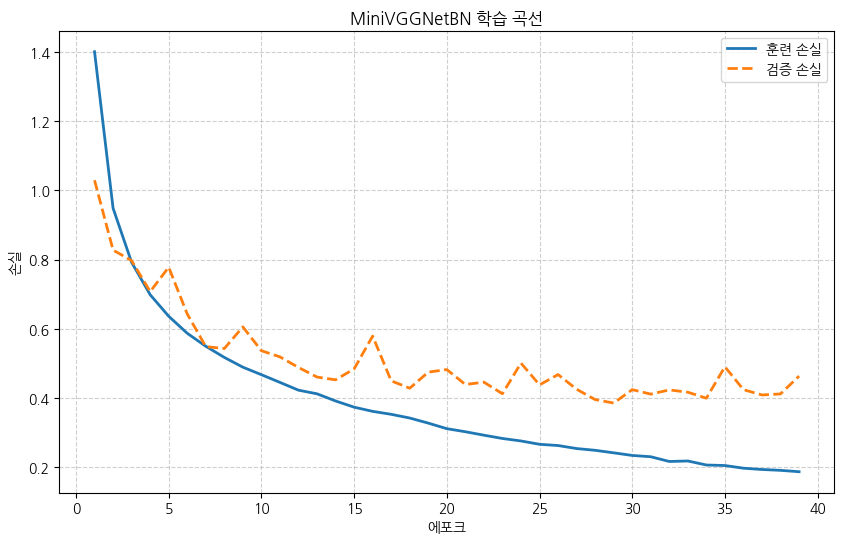

In [8]:
# 참고 - MiniVGGNetBN 모델 학습
import torch.optim as optim

# 모델마다 결과 재현을 위해 학습 전에 시드 고정
common.set_seed(SEED, deterministic=True)

# MiniVGGNetBN 모델 객체를 생성하고 학습 장치로 이동
model_vggbn = MiniVGGNetBN()
model_vggbn.to(device)                               

# 옵티마이저
optimizer = optim.Adam(model_vggbn.parameters(), lr=LR)

# 모델 학습
print('MiniVGGNetBN 학습')
log_vggbn = train_with_early_stopping(
    model_vggbn, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device
)

log_vggbn.plot(title='MiniVGGNetBN 학습 곡선', y_label='손실')

In [9]:
# 참고 - MiniVGGNetBN 모델의 평가

train_loss, train_acc = evaluate(model_vggbn, train_evaluate_loader, criterion, device)
test_loss, test_acc = evaluate(model_vggbn, test_loader, criterion, device)
print('MiniVGGNetBN 모델 평가(훈련 데이터셋)')
print(f'훈련 손실: {train_loss:.4f}, 정확도: {train_acc * 100:.2f}%')
print(f'MiniVGGNetBN 모델 평가(평가 데이터셋)')
print(f'평가 손실: {test_loss:.4f}, 정확도: {test_acc * 100:.2f}%')

MiniVGGNetBN 모델 평가(훈련 데이터셋)
훈련 손실: 0.1888, 정확도: 93.47%
MiniVGGNetBN 모델 평가(평가 데이터셋)
평가 손실: 0.4210, 정확도: 86.77%


- 본문 [표 8-3]의 수치(MiniVGGNet 43 에포크 / 89.44% / 83.38%, MiniVGGNetBN 29 에포크 / 93.19% / 86.27%)와 비교해 보자.
- 결과를 두 가지 관점에서 읽을 수 있다.
    - 최적 에포크가 43에서 29로 크게 줄었다. 배치 정규화로 학습이 안정되고 드롭아웃을 제거한 효과까지 더해져 더 적은 에포크로 최저 검증 손실에 도달했다.
    - 정확도가 2.89%p 개선되었고 훈련 정확도와 평가 정확도의 간격도 줄어들었다. 정확도와 일반화 성능이 모두 개선되었다는 뜻이다.

## 순전파 훅으로 배치 정규화 확인

- 모델의 성능 변화가 배치 정규화의 효과라고 말하려면 근거가 필요하다.
    - 순전파 과정에서 각 계층 출력의 평균과 표준편차를 직접 살펴봐야 한다.
- 값을 확인하려고 모델 클래스를 수정하는 일은 번거롭고, 실수로 모델의 동작을 바꿀 위험도 있으며, 소스 코드 접근 권한이 없으면 아예 불가능하다.
    - 훅은 모델을 수정하지 않고 문제점을 파악하고 전달되는 데이터나 기울기 값도 바꿀 수 있는 모델 전용 디버거다.
- `register_forward_hook()`으로 등록하는 훅 함수는 모듈(계층), 입력 텐서, 출력 텐서 순서로 인자를 받는다.
    - 여러 계층의 출력이 입력될 수 있으므로 입력은 튜플 형태다. 연결된 이전 계층이 하나뿐이므로 `inputs[0]`만 사용한다.

In [10]:
# 참고 - MiniVGGNetBN 모델의 첫 번째 배치 정규화 계층을 통과하는 데이터의 평균과 표준편차 확인
#   순전파 훅을 사용해 계산하고 출력
#   파이토치 훅에 대해서는 심화 학습 자료를 참고

# 계층 통과 전후 데이터의 평균과 표준편차를 계산해 출력하는 함수
#     register_forward_hook 메서드로 훅을 등록하는 경우의 인자
#         module: 훅을 등록할 계층
#         inputs: 계층으로 입력된 텐서
#             여러 계층의 출력이 입력될 수 있으므로 튜플 형태
#         output: 계층이 출력하는 텐서 
def data_inspect_hook(module, inputs, output):
    # 계층 입력 데이터의 평균과 표준편차
    # 이전 계층이 하나뿐이므로 inputs[0]만 계산
    input_mean = inputs[0].mean().item()
    input_std = inputs[0].std().item()
    # 계층 출력 데이터의 평균과 표준편차
    output_mean = output.mean().item()
    output_std = output.std().item()
    # 계층 통과 전후의 평균과 표준편차 출력
    print(f'   {input_mean:.2f}({input_std:.2f}) -> '
          f'{output_mean:.2f}({output_std:.2f})')

# 결과 재현을 위한 시드 고정
torch.manual_seed(SEED)

# 훅을 등록할 모델 (학습하지 않은 새 모델 생성)
model = MiniVGGNetBN()

# 훅을 추가할 계층: model.features의 첫 번째 VGG 블록의 두 번째 계층
target_layer = model.features[0][1]     # BatchNorm2d 계층

# 훅 등록: register_forward_hook
#     순전파에서 데이터가 등록한 계층을 통과할 때 등록한 훅 함수 호출
hook_handle = target_layer.register_forward_hook(data_inspect_hook)

# 1. 학습 모드에서의 배치 정규화 계층 통과 전후의 평균과 표준편차 확인
# 데이터가 target_layer를 지날 때 data_inspect_hook() 함수가 자동 실행
#     배치 정규화 계층 통과 전후의 평균과 표준편차 출력
print('배치 정규화 전 평균(표준편차) --> 배치 정규화 후 평균(표준편차)')
print('1. 학습 모드에서의 출력')
model.train()
# 데이터 증강이 적용되지 않은 train_evaluate_loader의 데이터 사용
for i, (inputs, labels) in enumerate(train_evaluate_loader):
    # 5개의 배치 입력에 대해서 확인
    if i == 5:
        break    
    output = model(inputs)              # 순전파 발생 -> 훅 실행

# 2. 평가 모드에서의 배치 정규화 계층 통과 전후의 평균과 표준편차 확인
print('\n2. 평가 모드에서의 출력')
model.eval()
for i, (inputs, labels) in enumerate(train_evaluate_loader):
    # 5개의 배치 입력에 대해서 확인    
    if i == 5:
        break
    output = model(inputs)

# 훅 핸들의 remove() 메서드로 제거
hook_handle.remove()

배치 정규화 전 평균(표준편차) --> 배치 정규화 후 평균(표준편차)
1. 학습 모드에서의 출력
   0.01(0.28) -> 0.00(1.00)


   0.01(0.29) -> 0.00(1.00)


   0.01(0.27) -> 0.00(1.00)
   0.01(0.28) -> -0.00(1.00)


   0.01(0.28) -> 0.00(1.00)

2. 평가 모드에서의 출력


   0.01(0.28) -> 0.01(0.34)
   0.01(0.29) -> 0.00(0.35)


   0.01(0.27) -> 0.00(0.34)
   0.01(0.28) -> 0.01(0.35)
   0.01(0.28) -> 0.01(0.35)


- 학습 모드에서는 정규화 전 평균과 표준편차가 배치마다 조금씩 다르더라도, 정규화를 거친 후에는 평균 0, 표준편차 1에 가깝게 맞춰진다.
- 평가 모드에서는 배치별 통계 대신 학습 중 누적해 둔 이동평균과 이동분산을 사용하므로, 정규화를 거치고도 표준편차가 1이 아닌 0.35 근처로 나타난다.
    - 배치 정규화가 학습 모드와 평가 모드에서 서로 다른 방식으로 동작한다는 것을 그대로 보여 주는 결과다.

## 역전파 훅으로 기울기 노름 확인([표 8-4])

- `register_full_backward_hook()`으로 등록하는 훅 함수는 모듈, 앞 계층으로 전달할 기울기(`grad_inputs`), 뒤 계층에서 전달된 기울기(`grad_outputs`) 순서로 인자를 받는다.
    - 사용하지 않는 인자도 자리를 채워야 한다.
- 합성곱 계층이 둘뿐인 `MiniAlexNet`은 두 계층의 값을, 합성곱 계층이 여섯 개인 나머지 모델은 첫 번째, 세 번째, 마지막 계층의 값을 측정한다.

> **텐서의 노름** — 수학에서 벡터의 노름은 원점으로부터의 거리와 비슷한 값이다. 딥러닝 분야에서는 텐서 요솟값들의 절대적인 크기로 텐서의 전반적인 강도를 알려 주는 지표로 주로 사용한다. 파이토치에서는 텐서의 `norm()` 메서드나 `torch.linalg.norm()` 함수로 계산할 수 있다.

In [11]:
# 참고 - MiniVGGNetBN 모델의 합성곱 계층 위치에 따른 기울기 신호(노름) 확인
#   역전파 훅을 사용해 계산하고 출력

# 노름: 벡터 또는 텐서가 얼마나 큰지를 비교하는 지표(원점에서의 거리와 비슷한 개념)

# MiniAlexNet의 두 합성곱 계층, MiniVGGNet과 MiniVGGNetBN의 첫 번째, 세 번째, 마지막 합성곱 계층의 값을 확인

# 모델에 역전파 기울기 출력의 노름을 반환하는 훅 함수(gradient_hook)를 등록하고, 
#   역전파를 수행하면서 목표 계층의 노름을 계산해 수집

def measure_grad_norms(model, named_layers, inputs, labels):
    # named_layers: [(계층 이름, 계층 객체), ...]
    norms = {name: None for name, _ in named_layers}
    handles = []

    # 역전파 훅을 생성하는 함수: 훅 함수를 반환
    def make_hook(name):
        def gradient_hook(module, grad_inputs, grad_outputs):
            norms[name] = grad_outputs[0].norm().item()
        return gradient_hook

    for name, layer in named_layers:
        # 반환된 훅 함수를 register_full_backward_hook() 메서드로 등록
        handles.append(layer.register_full_backward_hook(make_hook(name)))
    # 역전파 수행(주어진 데이터로 1회만 수행)
    model.train()
    criterion = nn.CrossEntropyLoss()
    output = model(inputs)
    loss = criterion(output, labels)
    loss.backward()
    for handle in handles:
        handle.remove()
    return norms

# 같은 시드로 초기화한 세 모델 객체 생성
torch.manual_seed(SEED)
m_alex = MiniAlexNet()
torch.manual_seed(SEED)
m_vgg = MiniVGGNet()
torch.manual_seed(SEED)
m_vggbn = MiniVGGNetBN()

# 첫 번째 배치 데이터만 사용
inputs, labels = next(iter(train_evaluate_loader))

# MiniAlexNet: 두 개의 합성곱 계층 모두 확인
alex_norms = measure_grad_norms(m_alex, [
    ('1', m_alex.conv_block_1.conv_block[0]),
    ('last', m_alex.conv_block_2.conv_block[0])
], inputs, labels)
# MiniVGGNet, MiniVGGNetBN: 여섯 개의 합성곱 계층 중 1번 째, 3번 째, 6번 째 계층 확인
vgg_norms = measure_grad_norms(m_vgg, [
    ('1', m_vgg.features[0][0]),
    ('3', m_vgg.features[1][0]),
    ('last', m_vgg.features[2][2])
], inputs, labels)
vggbn_norms = measure_grad_norms(m_vggbn, [
    ('1', m_vggbn.features[0][0]),
    ('3', m_vggbn.features[1][0]),
    ('last', m_vggbn.features[2][3])
], inputs, labels)

print(f'{"model":>6s} | {"MiniAlexNet":>12s} | {"MiniVGGNet":>12s} | {"MiniVGGNetBN":>12s}')
print('-' * 56)
for key in ['1', '3', 'last']:
    def fmt(x):
        return f'{x:.6f}' if x is not None else '-'
    print(f'{key:>6s} | {fmt(alex_norms.get(key)):>12s} | '
          f'{fmt(vgg_norms.get(key)):>12s} | '
          f'{fmt(vggbn_norms.get(key)):>12s}')

 model |  MiniAlexNet |   MiniVGGNet | MiniVGGNetBN
--------------------------------------------------------
     1 |     0.009919 |     0.000267 |     0.282153
     3 |            - |     0.001338 |     0.074192
  last |     0.021823 |     0.020678 |     0.056166


- 본문 [표 8-4]의 수치와 비교해 보자.

| 합성곱 계층 순서 | MiniAlexNet | MiniVGGNet | MiniVGGNetBN |
|---|---|---|---|
| 1 | 0.009919 | 0.000267 | 0.282153 |
| 3 | - | 0.001338 | 0.074192 |
| 마지막 | 0.021823 | 0.020678 | 0.056166 |

- 결과는 다음과 같이 해석할 수 있다.
    - **배치 정규화가 없는 모델의 기울기 소실 경향**: `MiniVGGNet`은 손실 기울기가 앞 계층으로 전달될수록 노름이 크게 줄어든다. 계층이 조금만 더 늘어나도 노름은 0에 수렴할 것으로 보인다.
    - **계층이 많을수록 심해지는 기울기 소실**: `MiniAlexNet`에서도 입력에 가까운 계층의 노름이 더 작지만, `MiniVGGNet`에 비하면 기울기 소실 경향이 덜하다.
    - **배치 정규화의 기울기 보강**: `MiniVGGNetBN`은 배치 정규화 덕분에 기울기를 잘 지켜내 기울기 소실 경향이 관찰되지 않는다. 오히려 첫 번째 합성곱 계층에서 노름이 가장 크다.

> **[심화 학습] 파이토치 훅** — 저장소의 `articles/pytorch-hook/`에서 배치 정규화와 잔차 학습의 효과를 확인하는 예제를 통해 파이토치 훅의 개념과 사용법을 설명하고 연습문제도 제공한다.

## 정리

- 배치 정규화 계층은 합성곱 계층 직후, 활성화 계층 이전에 배치한다. 합성곱 계층의 편향은 배치 정규화의 위치 파라미터와 역할이 겹쳐 `bias=False`로 둔다.
- 배치 정규화는 학습 모드와 평가 모드에서 다르게 동작한다. 평가 모드에서는 학습 중 누적한 이동평균과 이동분산을 사용한다.
- 배치 정규화는 수렴을 빠르게 하고 정확도와 일반화 성능을 함께 개선하며, 드롭아웃에 대한 의존도를 낮춘다.
- 훅을 사용하면 모델 클래스를 수정하지 않고 계층을 지나는 데이터와 기울기를 들여다볼 수 있다.